# PyGEM glacier thickness/bed inversion and dynamical spinup using OGGM

Brandon S. Tober<br>
30MAY2025<br>
<br>
This notebook goes through two things, ice thickness inversion and dynamical spinup, using OGGM's workflows, but with PyGEM's mass balance model.  First step is to do glacier bed/thickness inversion (using OGGM's `calibrate_inversion_from_consensus` task).  This is done for all glacier"s in a given region simultaneously (see [this OGGM tutorial](https://tutorials.oggm.org/stable/notebooks/tutorials/inversion.html)), to find a Glen"s A creep parameter that allows for the total regional ice volume from inversion to best match the regional reference ice volume (from Farinotti et al. 2019).  The only departure from OGGM's workflow and preprocessing here is that we pass PyGEM's mass balance model, and we ensure that debris is added to the flowline objects so that PyGEM's mass balance model can account for debris cover accordingly.

After doing regional inversion and Glen"s A calibration, we can perform dynamical spinup using OGGM's `run_dynamic_spinup` task.

In [1]:
### imports ###
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import numpy as np
import pandas as pd

from oggm import cfg, utils, workflow, tasks, graphics, global_tasks, DEFAULT_BASE_URL
from oggm.core import flowline
import matplotlib.pyplot as plt
import matplotlib.cm as cmx
import matplotlib.colors as mcolors

import pygem.pygem_modelsetup as modelsetup
from pygem import class_climate
from pygem.shop import debris
from oggm.core.flowline import FluxBasedModel, SemiImplicitModel
from pygem.oggm_compat import update_cfg
from pygem.massbalance import PyGEMMassBalance_wrapper, PyGEMMassBalance
from functools import partial

import logging
logging.getLogger("PIL.PngImagePlugin").setLevel(logging.WARNING)

# pygem imports
import pygem.setup.config as config
# check for config
config.ensure_config()
# read the config
pygem_prms = config.read_config()

# set some plotting defaults
plt.rcParams["font.family"] = "arial"
plt.rcParams["font.size"] = 10
plt.rcParams["legend.fontsize"] = 8
plt.rcParams["text.usetex"] = True

cfg.initialize(logging_level="WORKFLOW")
cfg.PATHS["working_dir"] = f"{pygem_prms["root"]}/{pygem_prms["oggm"]["oggm_gdir_relpath"]}"

def get_colors_from_cmap(cmap_name, N):
    cmap = plt.get_cmap(cmap_name)
    return [cmap(i / (N - 1)) for i in range(N)]

2025-05-31 18:16:49: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2025-05-31 18:16:49: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2025-05-31 18:16:49: oggm.cfg: Multiprocessing: using all available processors (N=10)


# SETUP

In [2]:
# OGGM configuration settings
# update_cfg({"baseline_climate" : "ERA5"}, "PARAMS")
update_cfg({"continue_on_error" : True}, "PARAMS")
update_cfg({"use_multiprocessing" : True}, "PARAMS")
update_cfg({"has_internet" : True}, "PARAMS")

2025-05-31 18:16:49: oggm.cfg: PARAMS['continue_on_error'] changed from `False` to `True`.
2025-05-31 18:16:49: oggm.cfg: Multiprocessing switched ON after user settings.


In [3]:
# Glacier Directory initialization for RGIId's of interest. Note, for inversion, we likely want all glaciers
# in a given region, but for testing maybe just a handful

main_glac_rgi = modelsetup.selectglaciersrgitable(rgi_regionsO1=[1]).iloc[[0,-1]]     # a subset for testing purposes
main_glac_rgi = modelsetup.selectglaciersrgitable(rgi_regionsO1=[1])
# main_glac_rgi = main_glac_rgi[main_glac_rgi.RGIId=="RGI60-01.15645"]
rgi_ids = main_glac_rgi["RGIId"].tolist()
gdirs = workflow.init_glacier_directories(rgi_ids, from_prepro_level=2, prepro_border=cfg.PARAMS["border"], 
                                                  prepro_base_url=pygem_prms["oggm"]["base_url"], prepro_rgi_version="62", reset=True, force=True);

This study is focusing on 27108 glaciers in region [1]
This study is focusing on 27108 glaciers in region [1]


2025-05-31 18:16:51: oggm.workflow: init_glacier_directories from prepro level 2 on 27108 glaciers.
2025-05-31 18:16:51: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 27108 glaciers


In [4]:
# PyGEM setup - model datestable, climate data import, prior model parameters 

# model dates
dt = modelsetup.datesmodelrun(startyear=1940, endyear=2019) # will have to cover the time period of inversion (2000-2019) and spinup (1979-~2010 by default)
# load climate data
ref_clim = class_climate.GCM(name="ERA5")

# Air temperature [degC]
temp, _ = ref_clim.importGCMvarnearestneighbor_xarray(ref_clim.temp_fn, ref_clim.temp_vn, main_glac_rgi, dt)
# Precipitation [m]
prec, _ = ref_clim.importGCMvarnearestneighbor_xarray(ref_clim.prec_fn, ref_clim.prec_vn, main_glac_rgi, dt)
# Elevation [m asl]
elev = ref_clim.importGCMfxnearestneighbor_xarray(ref_clim.elev_fn, ref_clim.elev_vn, main_glac_rgi)
# Lapse rate [degC m-1]
lr, _ = ref_clim.importGCMvarnearestneighbor_xarray(ref_clim.lr_fn, ref_clim.lr_vn, main_glac_rgi, dt)

# load prior regionally averaged modelprms (from Rounce et al. 2023)
priors_df = pd.read_csv(pygem_prms["root"] + "/Output/calibration/" + pygem_prms["calib"]["priors_reg_fn"])

# loop through gdirs and add `glacier_rgi_table`, `historical_climate`, `dates_table` and `modelprms` attributes to each glacier directory
for i, gd in enumerate(gdirs):
    # Select subsets of data
    gd.glacier_rgi_table = main_glac_rgi.loc[main_glac_rgi.index.values[i], :]
    # Add climate data to glacier directory (first inversion data)
    gd.historical_climate = {"elev": elev[i],
                            "temp": temp[i,:],
                            "tempstd": np.zeros(temp[i,:].shape),
                            "prec": prec[i,:],
                            "lr": lr[i,:]}
    gd.dates_table = dt

    # get modelprms from regional priors
    priors_idx = np.where((priors_df.O1Region == gd.glacier_rgi_table["O1Region"]) & 
                                                (priors_df.O2Region == gd.glacier_rgi_table["O2Region"]))[0][0]
    tbias_mu = float(priors_df.loc[priors_idx, "tbias_mean"])
    kp_mu = float(priors_df.loc[priors_idx, "kp_mean"])
    gd.modelprms = {"kp": kp_mu,
                        "tbias": tbias_mu,
                        "ddfsnow": pygem_prms["calib"]["MCMC_params"]["ddfsnow_mu"],
                        "ddfice": pygem_prms["calib"]["MCMC_params"]["ddfsnow_mu"] / pygem_prms["sim"]["params"]["ddfsnow_iceratio"],
                        "precgrad": pygem_prms["sim"]["params"]["precgrad"],
                        "tsnow_threshold": pygem_prms["sim"]["params"]["tsnow_threshold"]}

# PREPROCESSING

In [5]:
task_list = [
    tasks.process_climate_data,                 # process climate_hisotrical data to gdir
    debris.debris_to_gdir,                      # process debris data to gdir
    debris.debris_binned                        # add debris to inversion flowlines
]
for task in task_list:
    workflow.execute_entity_task(task, gdirs);

2025-05-31 18:28:09: oggm.workflow: Execute entity tasks [process_climate_data] on 27108 glaciers
2025-05-31 18:31:06: oggm.workflow: Execute entity tasks [debris_to_gdir] on 27108 glaciers
2025-05-31 18:31:38: oggm.workflow: Execute entity tasks [debris_binned] on 27108 glaciers


# INVERSION

In [6]:
# process mb_calib data from geodetic mass balance
workflow.execute_entity_task(tasks.mb_calibration_from_geodetic_mb,
                            gdirs, informed_threestep=True, overwrite_gdir=True,
                            );

#############################
### glacier bed inversion ###
#############################
# note, PyGEMMassBalance_wrapper is passed to `tasks.apparent_mb_from_any_mb` as the `mb_model_class` so that PyGEMs mb model is used for inversion
workflow.execute_entity_task(tasks.apparent_mb_from_any_mb, gdirs, 
                             mb_model_class=partial(PyGEMMassBalance_wrapper, fl_str="inversion_flowlines"));
# since inversion_flowlines.pkl were overwritten by `apparent_mb_from_any_mb`, add debris data back to flowlines
workflow.execute_entity_task(debris.debris_binned, gdirs, fl_str="inversion_flowlines");
cdf = workflow.calibrate_inversion_from_consensus(
    gdirs,
    apply_fs_on_mismatch=True,
    error_on_mismatch=True,  # if you running many glaciers some might not work
    filter_inversion_output=True,  # this partly filters the overdeepening due to
    # the equilibrium assumption for retreating glaciers (see. Figure 5 of Maussion et al. 2019)
    volume_m3_reference=None,  # here you could provide your own total volume estimate in m3
);

# finally create the dynamic flowlines
workflow.execute_entity_task(tasks.init_present_time_glacier, gdirs);

# add debris to model_flowlines
workflow.execute_entity_task(debris.debris_binned, gdirs, fl_str="model_flowlines");

2025-05-31 18:31:52: oggm.workflow: Execute entity tasks [mb_calibration_from_geodetic_mb] on 27108 glaciers
RuntimeError occurred during task mb_calibration_from_scalar_mb on RGI60-01.24246: RGI60-01.24246: we tried very hard but we could not find a combination of parameters that works for this ref mb.
RuntimeError occurred during task mb_calibration_from_scalar_mb on RGI60-01.24248: RGI60-01.24248: we tried very hard but we could not find a combination of parameters that works for this ref mb.
RuntimeError occurred during task mb_calibration_from_scalar_mb on RGI60-01.24600: RGI60-01.24600: we tried very hard but we could not find a combination of parameters that works for this ref mb.
RuntimeError occurred during task mb_calibration_from_scalar_mb on RGI60-01.24602: RGI60-01.24602: we tried very hard but we could not find a combination of parameters that works for this ref mb.
RuntimeError occurred during task mb_calibration_from_scalar_mb on RGI60-01.24603: RGI60-01.24603: we tried

In [7]:
cdf.sum()

vol_itmix_m3        1.897846e+13
vol_bsl_itmix_m3    1.077419e+12
vol_oggm_m3         1.897061e+13
dtype: float64

Text(0, 0.5, 'vol_oggm_m3')

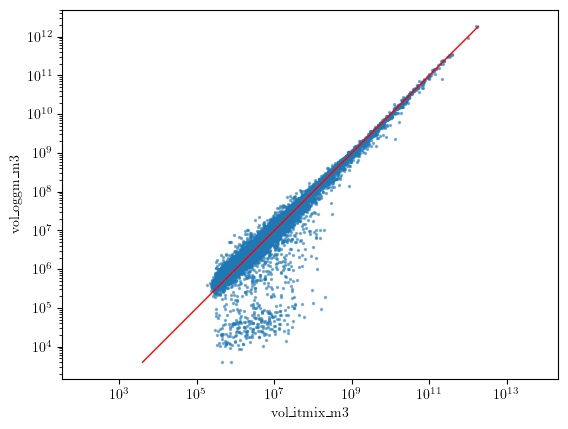

In [8]:
fig,ax = plt.subplots(1)

ax.scatter(cdf.vol_itmix_m3.values, cdf.vol_oggm_m3.values, alpha=.5, s=2)

# Determine range for 1:1 line
min_val = min(cdf.vol_itmix_m3.min(), cdf.vol_oggm_m3.min())
max_val = max(cdf.vol_itmix_m3.max(), cdf.vol_oggm_m3.max())
# Plot 1:1 line
ax.plot([min_val, max_val], [min_val, max_val], 'r', lw=1)
ax.set_yscale('log')
ax.set_xscale('log')
ax.axis('equal')
ax.set_xlabel('vol_itmix_m3')
ax.set_ylabel('vol_oggm_m3')

# SPINUP
For dynamical spinup, we run the dynamical model attempting to find a dynamical state at the specified `spinup_start_yr` which leads to a match to the specified `minimise_for` variable (RGI area by default) at the specified `target_yr`.  As with inversion, we"ll use PyGEM's mass balance model for this task (now passed as the `mb_model_historical` variable).  A departure from the way PyGEM's mass balaance model was passed to the inversion task, is that `run_dynamic_spinup` expects `mb_model_historical` to already be instantiated - thus, we cannot run all glaciers simultaneously using something like so:

```{python}
workflow.execute_entity_task(tasks.run_dynamic_spinup,
    gdirs,
    mb_model_historical = partial(PyGEMMassBalance_wrapper, fl_str="model_flowlines")
```

We"ll have to instead loop through each gdir, and pass `mb_model_historical` as an instantiated mb model class.  Here, we"ll just demonstrate on a single glacier, but will then run all glaciers in parallel in a separate `run_spinup` script.

In [9]:
# get glacier of interest
gd = next((obj for obj in gdirs if obj.rgi_id == "RGI60-01.00570"), gdirs[0])

In [ ]:
# perform OGGM dynamic spinup
tasks.run_dynamic_spinup(
        gd,
        # spinup_start_yr=1940,  # When to start the spinup
        target_yr=2000, # The year at which we want to match area or volume. If None, gdir.rgi_date + 1 is used (the default)
        minimise_for="area",  # what target to match at the target_yr
        ye=2020,  # When the simulation should stop
        # model_flowline_filesuffix="_pygem_mb",  # The suffix of the model file to start from
        output_filesuffix=f"_dynamic_spinup_pygem_mb",
        store_fl_diagnostics=True,
        store_model_geometry=True,
        # first_guess_t_spinup = , could be passed as input argument for each step in the sampler based on prior tbias, current default first guess is -2
        mb_model_historical = PyGEMMassBalance_wrapper(gd, fl_str="model_flowlines"),
        );        

# load flowline_diagnostics from spinup
f = gd.get_filepath("fl_diagnostics",filesuffix="_dynamic_spinup_pygem_mb")
with xr.open_dataset(f, group=f"fl_0") as ds_spn:
    # The data is compressed - it"s a good idea to store it to memory
    # before playing with it
    ds_spn = ds_spn.load()


# instantiate flowline.FileModel object from model_geometry_dynamic_spinup
fmd_dynamic = flowline.FileModel(gd.get_filepath("model_geometry", filesuffix=f"_dynamic_spinup_pygem_mb"))
# run FileModel to year 2000 (it will be initialized at `spinup_start_yr`)
# Bring it to year 2000
fmd_dynamic.run_until(2000);
# write flowlines
gd.write_pickle(fmd_dynamic.fls, "model_flowlines", filesuffix="_2000");
# add debris
debris.debris_binned(gd, fl_str="model_flowlines", filesuffix="_2000");
fls = gd.read_pickle("model_flowlines", filesuffix="_2000")

# QC

Plot various components along glacier flowline (climatic mass balance, dhdt, flux divergence, initial thickness)

Text(0.5, 1.0, 'RGI60-01.00570')

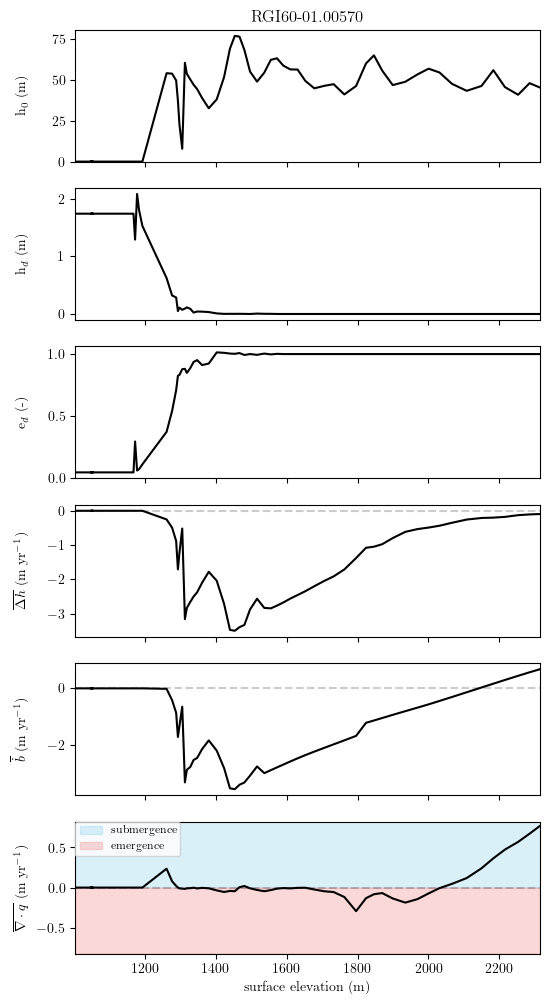

In [11]:
fig,ax=plt.subplots(6,sharex=True,figsize=(6,12))
surface_h = ds_spn.bed_h.values + ds_spn.sel(time=2000).thickness_m.values
ax[0].plot(surface_h, ds_spn.sel(time=2000).thickness_m,'k')
ax[1].plot(surface_h, fls[0].debris_hd,'k')
ax[2].plot(surface_h, fls[0].debris_ed,'k')
ax[3].plot(surface_h, np.nanmean(ds_spn.sel(time=slice('2000', '2020')).dhdt_myr.values,axis=0), 'k')
ax[4].plot(surface_h, np.nanmean(ds_spn.sel(time=slice('2000', '2020')).climatic_mb_myr.values,axis=0), 'k')
ax[5].plot(surface_h, -1*np.nanmean(ds_spn.sel(time=slice('2000', '2020')).flux_divergence_myr.values,axis=0), 'k')

# idx_dh_min = np.nanargmin(delta_h_annual.mean(axis=1))

ax[-1].set_xlabel('surface elevation (m)')
ax[0].set_ylabel(r'h$_{0}$ (m)')
ax[0].set_ylim([0, ax[0].get_ylim()[1]])
ax[1].set_ylabel(r'h$_{d}$ (m)')
ax[2].set_ylabel(r'e$_{d}$ (-)')
ax[3].set_ylabel(r'$\overline{\Delta h}$ (m yr$^{-1}$)')
ax[3].axhline(0, color='k', alpha=.2, ls='--')
ax[4].set_ylabel(r'$\overline{\dot{b}}$ (m yr$^{-1}$)')
ax[4].axhline(0, color='k', alpha=.2, ls='--')
ax[5].set_ylabel(r'$\overline{\nabla \cdot q}$ (m yr$^{-1}$)')
ax[5].axhline(0, color='k', alpha=.2, ls='--')
ylims = ax[5].get_ylim()
ax[0].set_xlim([surface_h.min(),surface_h.max()])
ylims = [-np.max(np.abs(ylims)), np.max(np.abs(ylims))]
x=np.arange(ax[5].get_xlim()[0],ax[5].get_xlim()[1],1)
ax[5].fill_between(x, 0, ylims[1], color='skyblue', alpha=0.3, label='submergence')
ax[5].fill_between(x, 0,ylims[0], color='lightcoral', alpha=0.3, label='emergence')
ax[5].set_ylim(ylims)
ax[5].legend(borderaxespad=0,loc='upper left')

for a in ax:
    a.yaxis.set_label_coords(-0.1, 0.5)
ax[0].set_title(f'{gd.rgi_id}')

Text(0.5, 1.0, 'RGI60-01.00570')

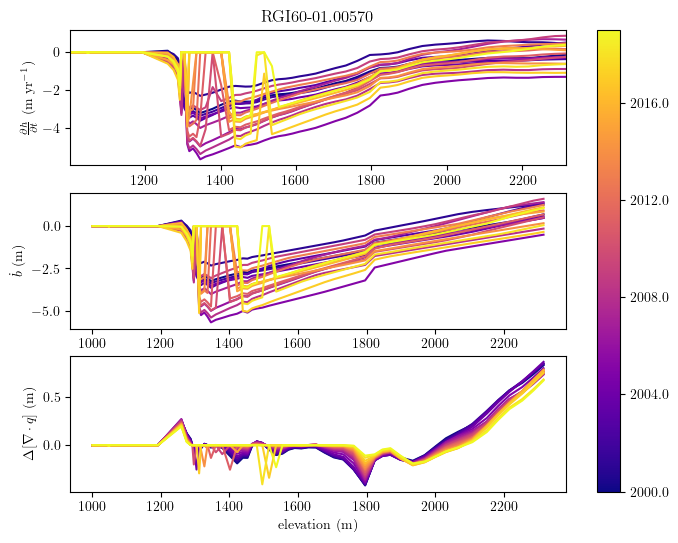

In [12]:
# Get number of years and color map
years = ds_spn.sel(time=slice('2000', '2020')).time.values

# Set up figure and axis
fig, ax = plt.subplots(3,figsize=(8, 6))

# Create colormap and normalization
cmap = plt.get_cmap('plasma')
norm = mcolors.Normalize(vmin=years[0], vmax=years[-1])
scalar_map = cmx.ScalarMappable(norm=norm, cmap=cmap)

# Plot each line with corresponding color
for i, year in enumerate(years):
    ax[0].plot(surface_h, ds_spn.sel(time=slice('2000', '2020')).dhdt_myr.values[i, :],
            c=scalar_map.to_rgba(year))
    ax[1].plot(surface_h, ds_spn.sel(time=slice('2000', '2020')).climatic_mb_myr.values[i, :],
            c=scalar_map.to_rgba(year))
    ax[2].plot(surface_h, -1*ds_spn.sel(time=slice('2000', '2020')).flux_divergence_myr.values[i, :],
            c=scalar_map.to_rgba(year))

# Add colorbar with integer year ticks
cbar = fig.colorbar(scalar_map, ax=ax)

# Set colorbar ticks to integers, spaced reasonably
tick_step = max(1, len(years) // 5)  # Adjust number of ticks if needed
cbar.set_ticks(years[::tick_step])
cbar.set_ticklabels(years[::tick_step])

# Axis labels
ax[0].set_ylabel(r'$\frac{\partial h}{\partial t}$ (m yr$^{-1}$)')
ax[1].set_ylabel(r'$\dot{b}$ (m)')
ax[2].set_ylabel(r'$\Delta [ \nabla \cdot q ]$ (m)')
ax[2].set_xlabel('elevation (m)')
ax[0].set_xlim([surface_h.min(),surface_h.max()])
ax[0].set_title(f'{gd.rgi_id}')


Check that dynamical spinup run outputs agree with a cold-start (what we"d do when running model calibration following spinup)

## SETUP

Take one of the gdirs - grab model_flowlines from model_geometry produced by dynamic spinup to run dynamical model from "cold-start" over 2000-2020 period

In [13]:
# instantiate flowline.FileModel object from model_geometry_dynamic_spinup
fmd_dynamic = flowline.FileModel(gd.get_filepath("model_geometry", filesuffix=f"_dynamic_spinup_pygem_mb"))
# run FileModel to year 2000 (it will be initialized at `spinup_start_yr`)
print(f"Flowline model for {gd.rgi_id} initialized at year {fmd_dynamic.yr}")
# Bring it to year 2000
fmd_dynamic.run_until(2000);
# write flowlines
gd.write_pickle(fmd_dynamic.fls, "model_flowlines", filesuffix="_2000");
# add debris
debris.debris_binned(gd, fl_str="model_flowlines", filesuffix="_2000");

Flowline model for RGI60-01.00570 initialized at year 1940.0


## COLD START RUN

In [14]:
### RUN DYNAMICS ###
cls = gd.read_pickle("inversion_input")[-1]
th = cls["hgt"][-1]
vmin, vmax = cfg.PARAMS["free_board_marine_terminating"]
water_level = utils.clip_scalar(0, th - vmax, th - vmin) 
# mass balance model with evolving area
mbmod = PyGEMMassBalance(gd, gd.modelprms, gd.glacier_rgi_table,
                            fls=gd.read_pickle("model_flowlines", filesuffix="_2000"))
glen_a=gd.get_diagnostics()["inversion_glen_a"]
fs = gd.get_diagnostics()["inversion_fs"]

# glacier dynamics model
ev_model = SemiImplicitModel(gd.read_pickle("model_flowlines", filesuffix="_2000"),
                            y0=2000, mb_model=mbmod, 
                            glen_a=glen_a, fs=fs,
                            is_tidewater=gd.is_tidewater,
                            water_level=water_level);

# run glacier dynamics model forward
_, ds_cs = ev_model.run_until_and_store(2020,
                             fl_diag_path=True);
ds_cs = ds_cs[0]
ds_cs

<xarray.Dataset> Size: 161kB
Dimensions:              (dis_along_flowline: 104, time: 21)
Coordinates:
  * dis_along_flowline   (dis_along_flowline) float64 832B 0.0 ... 1.421e+04
  * time                 (time) float64 168B 2e+03 2.001e+03 ... 2.02e+03
Data variables: (12/13)
    point_lons           (dis_along_flowline) float64 832B -145.6 ... -145.3
    point_lats           (dis_along_flowline) float64 832B 63.35 63.35 ... 63.35
    bed_h                (dis_along_flowline) float64 832B 2.271e+03 ... 1.00...
    volume_m3            (time, dis_along_flowline) float64 17kB 3.626e+06 .....
    volume_bsl_m3        (time, dis_along_flowline) float64 17kB 0.0 0.0 ... 0.0
    volume_bwl_m3        (time, dis_along_flowline) float64 17kB 0.0 0.0 ... 0.0
    ...                   ...
    thickness_m          (time, dis_along_flowline) float64 17kB 45.23 ... 0.0
    ice_velocity_myr     (time, dis_along_flowline) float64 17kB nan nan ... 0.0
    calving_bucket_m3    (time) float64 168B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    flux_divergence_myr  (time, dis_along_flowline) float64 17kB nan nan ... 0.0
    climatic_mb_myr      (time, dis_along_flowline) float64 17kB nan nan ... 0.0
    dhdt_myr             (time, dis_along_flowline) float64 17kB nan nan ... 0.0
Attributes: (12/21)
    class:                      MixedBedFlowline
    map_dx:                     69.0
    dx:                         2.0
    description:                OGGM model output
    oggm_version:               1.6.2
    calendar:                   365-day no leap
    ...                         ...
    mb_model_is_tidewater:      0
    mb_model_glacier_gcm_elev:  1344.5230805834728
    mb_model_nmonths:           960
    mb_model_nyears:            80
    mb_model_firnline_idx:      0
    mb_model_sea_level:         0

# SPINUP RUN

In [15]:
# load flowline_diagnostics from spinup
f = gd.get_filepath("fl_diagnostics",filesuffix="_dynamic_spinup_pygem_mb")
with xr.open_dataset(f, group=f"fl_0") as ds_spn:
    # The data is compressed - it"s a good idea to store it to memory
    # before playing with it
    ds_spn = ds_spn.load()

In [16]:
ds_spn

<xarray.Dataset> Size: 611kB
Dimensions:              (dis_along_flowline: 104, time: 81)
Coordinates:
  * dis_along_flowline   (dis_along_flowline) float64 832B 0.0 ... 1.421e+04
  * time                 (time) float64 648B 1.94e+03 1.941e+03 ... 2.02e+03
Data variables: (12/13)
    point_lons           (dis_along_flowline) float64 832B -145.6 ... -145.3
    point_lats           (dis_along_flowline) float64 832B 63.35 63.35 ... 63.35
    bed_h                (dis_along_flowline) float64 832B 2.271e+03 ... 1.00...
    volume_m3            (time, dis_along_flowline) float64 67kB 4.676e+06 .....
    volume_bsl_m3        (time, dis_along_flowline) float64 67kB 0.0 0.0 ... 0.0
    volume_bwl_m3        (time, dis_along_flowline) float64 67kB 0.0 0.0 ... 0.0
    ...                   ...
    thickness_m          (time, dis_along_flowline) float64 67kB 57.16 ... 0.0
    ice_velocity_myr     (time, dis_along_flowline) float64 67kB nan nan ... 0.0
    calving_bucket_m3    (time) float64 648B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    flux_divergence_myr  (time, dis_along_flowline) float64 67kB nan nan ... 0.0
    climatic_mb_myr      (time, dis_along_flowline) float64 67kB nan nan ... 0.0
    dhdt_myr             (time, dis_along_flowline) float64 67kB nan nan ... 0.0
Attributes: (12/13)
    description:          OGGM model output
    water_level:          0
    dx:                   2.0
    creation_date:        2025-05-31 22:46:12
    fs:                   0
    mb_model_class:       PyGEMMassBalance_wrapper
    ...                   ...
    class:                MixedBedFlowline
    glen_a:               5.219473672934105e-24
    oggm_version:         1.6.2
    mb_model_rho:         900.0
    mb_model_hemisphere:  nh
    calendar:             365-day no leap

# COMPARISON

Text(0.05, 0.5, 'Flux divergence (m yr$^{-1}$)')

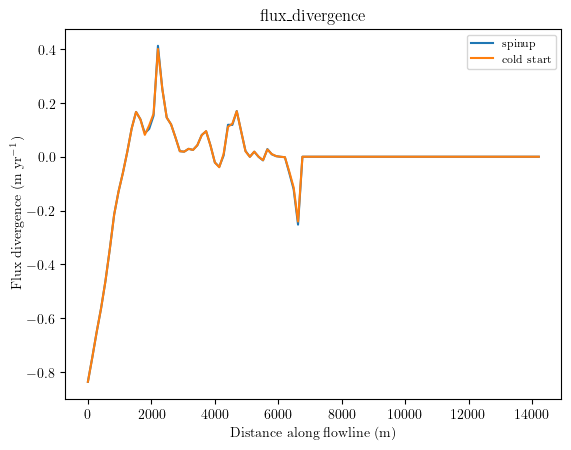

In [17]:
fig,ax=plt.subplots(1)
ax.plot(ds_spn.dis_along_flowline.values, ds_spn.sel(time=2001).flux_divergence_myr.values, label="spinup")
ax.plot(ds_cs.dis_along_flowline.values, ds_cs.sel(time=2001).flux_divergence_myr.values, label="cold start")
ax.legend(); ax.set_title("flux_divergence");
ax.set_xlabel("Distance along flowline (m)")
fig.text(0.05,.5,"Flux divergence (m yr$^{-1}$)",rotation=90,ha="center",va="center")

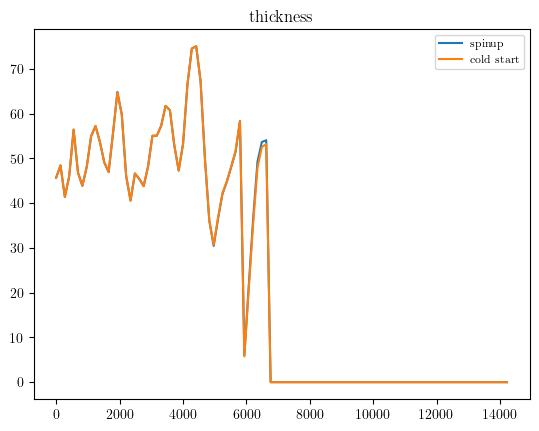

In [18]:
fig,ax=plt.subplots(1)
ax.plot(ds_spn.dis_along_flowline, ds_spn.sel(time=2001).thickness_m, label="spinup")
ax.plot(ds_cs.dis_along_flowline, ds_cs.sel(time=2001).thickness_m, label="cold start")
ax.legend(); ax.set_title("thickness");

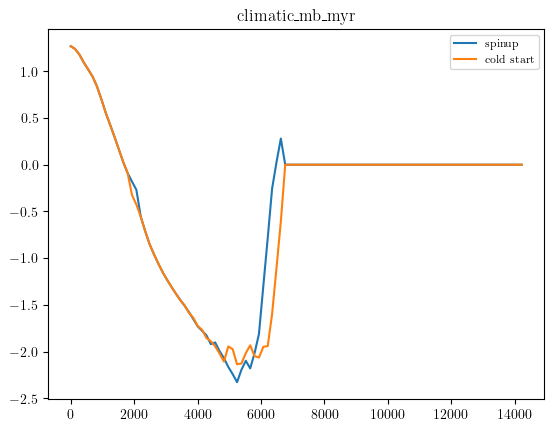

In [19]:
fig,ax=plt.subplots(1)
ax.plot(ds_spn.dis_along_flowline, ds_spn.sel(time=2001).climatic_mb_myr, label="spinup")
ax.plot(ds_cs.dis_along_flowline, ds_cs.sel(time=2001).climatic_mb_myr, label="cold start")
ax.legend(); ax.set_title("climatic_mb_myr");

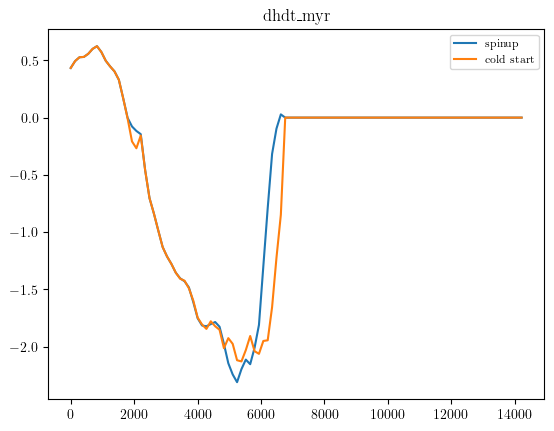

In [20]:
fig,ax=plt.subplots(1)
ax.plot(ds_spn.dis_along_flowline, ds_spn.sel(time=2001).dhdt_myr, label="spinup")
ax.plot(ds_cs.dis_along_flowline, ds_cs.sel(time=2001).dhdt_myr, label="cold start")
ax.legend(); ax.set_title("dhdt_myr");

In [21]:
print(ds_cs.glen_a, ds_cs.fs)

5.219473672934105e-24 0


In [22]:
print(ds_spn.glen_a, ds_spn.fs)

5.219473672934105e-24 0


We now have a workflow to run bed inversion and dynamical spinup using PyGEM's mass balance model.  Taking this workfow, can run dynamical spinup over glaciers of interest in parallel using a separate script `run_spinup.py`:

E.g.
```{python}
run_spinup -rgi_glac_number {glac_no} -spinup_start_yr 1979 -target_yr 2000
```